<a href="https://colab.research.google.com/github/lodenaq/SUNY-Canton-Projects/blob/main/DATA315_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(90deg, #071126, #1d4ed8); color: white; padding: 22px 28px; border-radius: 18px; font-family: 'Tahoma', sans-serif; max-width: 800px; box-sizing: border-box;">
  <h1 style="margin: 0; font-size: 28px; font-weight: normal; letter-spacing: -0.5px;">
    Project Code: Internet Advertising Dataset
  </h1>
  <p style="margin: 10px 0 0 0; font-size: 13.5px; opacity: 0.95; word-spacing: 1px;">
    Spring 2026 DATA315 • Final Project • Pat Dispenza • SUNY Canton
  </p>
</div>
  
### The goal of this project is to identify internet ads vs. web content through the processing of captured data using a machine learning workflow.  

Utilizing the **Internet Advertising Dataset**, an insightful analysis will be achieved by:

- loading and inspecting data
- exploring patterns visually
- splitting data into training and testing sets
- creating a simple baseline
- training multiple models
- tune a model with cross-validation
- evaluate predictions clearly
- interpret a tree-based model


## Roadmap

We will follow this workflow:

**Import tools -> Load data -> Explore data -> Prepare features -> Split data -> Build baseline -> Train models -> Tune best model -> Evaluate results -> Interpret model**

## 1. Import libraries

This cell imports the Python libraries we need.

### Why this matters
Different libraries do different jobs:
- **pandas** helps us work with tables
- **numpy** supports numerical work
- **matplotlib** and **seaborn** help us visualize data
- **scikit-learn** provides machine learning tools

In [ ]:
# Ignore warnings to keep the notebook output clean and readable.
import warnings
warnings.filterwarnings("ignore")

# Core data science libraries.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning tools from scikit-learn.
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/final project/ad.data', low_memory=False)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,classification_report,
    confusion_matrix
)

# Make plots look cleaner and set a seed for reproducibility.
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Mounted at /content/drive
Libraries imported successfully.


In [ ]:
# Add na_values to catch the 'noisy' question marks right at the start.
# The original last column of the raw data contains the class labels ('ad.' or 'nonad.').
raw_df = pd.read_csv('/content/drive/MyDrive/final project/ad.data',
                 low_memory=False,
                 header=None,
                 na_values=["", " ?", "  ?", "   ?", "    ?"]) # Extended na_values to catch more variations

# Extract the original class labels from the last column of the raw DataFrame.
# This will become our target variable 'y'.
original_raw_class_labels = raw_df.iloc[:, -1]

# Create 'class_name' by cleaning the raw labels (removing the trailing dot).
class_name = original_raw_class_labels.astype(str).str.replace('.', '', regex=False)

# Convert 'class_name' to numeric codes for 'class_id'.
class_id = class_name.astype('category').cat.codes

# Now, define 'df' to contain *only* the features by dropping the original last column
# from the raw_df. This aligns with the expectation for a feature matrix (X).
df = raw_df.iloc[:, :-1]

# Explicitly convert all feature columns to numeric, coercing errors to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# Updated Missing Values Check
print("Total Missing Values per Column (First 5 Columns):")
print(df.iloc[:, :5].isnull().sum())

print("\nTotal Missing Values in entire dataset:", df.isnull().sum().sum())

# Show basic information and the first few rows of the features DataFrame.
print("Dataset shape (features only):", df.shape)
print("\nColumn names (first 10): ")
print(df.columns[:10].tolist())

print("\nFirst 5 values of class_name (target labels):")
print(class_name.head())
print("\nFirst 5 values of class_id (numeric target labels):")
print(class_id.head())

df.head()

Total Missing Values per Column (First 5 Columns):
0    903
1    901
2    910
3     15
4      0
dtype: int64

Total Missing Values in entire dataset: 2729
Dataset shape (features only): (3279, 1558)

Column names (first 10): 
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

First 5 values of class_name (target labels):
0    ad
1    ad
2    ad
3    ad
4    ad
Name: 1558, dtype: object

First 5 values of class_id (numeric target labels):
0    0
1    0
2    0
3    0
4    0
dtype: int8


,0,1,2,3,4,5,6,7,8,9,...,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557
0,125.0,125.0,1.0000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57.0,468.0,8.2105,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,33.0,230.0,6.9696,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Take a first look at the data

Before building a model, we should understand the structure of the dataset.

This helps us answer questions like:
- Are there missing values?
- Are the classes balanced?
- What do the numbers look like?

In [ ]:
print("Number of rows and columns:", df.shape)

# In this dataset, the target column is usually named "class"
# containing labels like "ad" and "nonad"
print("\nAvailable classes:")
print(class_name.unique())

print("\nFirst 5 rows:")
display(df.head())

Number of rows and columns: (3279, 1558)

Available classes:
['ad' 'nonad']

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557
0,125.0,125.0,1.0000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57.0,468.0,8.2105,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,33.0,230.0,6.9696,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Check for missing values and class balance

### Why this matters
- Missing values can break parts of the modeling process.
- Class imbalance can make accuracy misleading.

For Iris, we expect a clean and balanced dataset.

In [ ]:
# Check for missing data in every column.
print("Missing values by column:")
print(df.isnull().sum())

# Display the size of the dataset and the class labels.
print("Number of rows and columns:", df.shape)

# In this dataset, the target column is usually named "class"
# containing labels like "ad" and "nonad"
print("\nAvailable classes:")
print(class_name.unique())

print("\nFirst 5 rows:")

Missing values by column:
0       903
1       901
2       910
3        15
4         0
       ... 
1553      0
1554      0
1555      0
1556      0
1557      0
Length: 1558, dtype: int64
Number of rows and columns: (3279, 1558)

Available classes:
['ad' 'nonad']

First 5 rows:


In [ ]:
# Add na_values to catch the 'noisy' question marks right at the start.
# The original last column of the raw data contains the class labels ('ad.' or 'nonad.').
raw_df = pd.read_csv('/content/drive/MyDrive/final project/ad.data',
                 low_memory=False,
                 header=None,
                 na_values=["", " ?", " ?"])

# Extract the original class labels from the last column of the raw DataFrame.
# This will become our target variable 'y'.
original_raw_class_labels = raw_df.iloc[:, -1]

# Create 'class_name' by cleaning the raw labels (removing the trailing dot).
class_name = original_raw_class_labels.astype(str).str.replace('.', '', regex=False)

# Convert 'class_name' to numeric codes for 'class_id'.
class_id = class_name.astype('category').cat.codes

# Now, define 'df' to contain *only* the features by dropping the original last column
# from the raw_df. This aligns with the expectation for a feature matrix (X).
df = raw_df.iloc[:, :-1]

# Show basic information and the first few rows of the features DataFrame.
print("Dataset shape (features only):", df.shape)
print("\nColumn names (first 10): ")
print(df.columns[:10].tolist())

print("\nFirst 5 values of class_name (target labels):")
print(class_name.head())
print("\nFirst 5 values of class_id (numeric target labels):")
print(class_id.head())

df.head()

Dataset shape (features only): (3279, 1558)

Column names (first 10): 
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

First 5 values of class_name (target labels):
0    ad
1    ad
2    ad
3    ad
4    ad
Name: 1558, dtype: object

First 5 values of class_id (numeric target labels):
0    0
1    0
2    0
3    0
4    0
dtype: int8


,0,1,2,3,4,5,6,7,8,9,...,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557
0,125,125,1.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57,468,8.2105,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,33,230,6.9696,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Summary statistics

This cell gives us a statistical summary of the numeric columns.

### Look for
- average values
- minimum and maximum values
- spread of the data

In [ ]:
# Summary statistics help us understand the scale and range of each feature.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,2376.0,64.021886,54.868604,1.0000,25.0000,51.000,85.2500,640.0
1,2378.0,155.344828,130.032350,1.0000,80.0000,110.000,184.0000,640.0
2,2369.0,3.911953,6.042986,0.0015,1.0357,2.102,5.3333,60.0
3,3264.0,0.767157,0.422708,0.0000,1.0000,1.000,1.0000,1.0
4,3279.0,0.004270,0.065212,0.0000,0.0000,0.000,0.0000,1.0
...,...,...,...,...,...,...,...,...
1553,3279.0,0.006404,0.079783,0.0000,0.0000,0.000,0.0000,1.0
1554,3279.0,0.012809,0.112466,0.0000,0.0000,0.000,0.0000,1.0
1555,3279.0,0.013419,0.115077,0.0000,0.0000,0.000,0.0000,1.0
1556,3279.0,0.009759,0.098320,0.0000,0.0000,0.000,0.0000,1.0


## 6. Visualize class distribution

A count plot shows how many examples we have in each species.

### Why this matters
Balanced classes usually make classification easier to evaluate fairly.

In [ ]:
# Display the size of the dataset and the class labels.
print("Number of rows and columns:", df.shape)

# In this dataset, the target column is usually named "class"
# containing labels like "ad" and "nonad"
print("\nAvailable classes:")
print(class_name.unique())

print("\nFirst 5 rows:")
display(df.head())

Number of rows and columns: (3279, 1558)

Available classes:
['ad' 'nonad']

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557
0,125.0,125.0,1.0000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57.0,468.0,8.2105,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,33.0,230.0,6.9696,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,60.0,468.0,7.8000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 7. Compare feature relationships with a pair plot

A **pair plot** helps us see how features relate to each other.

### Why this matters
If classes separate clearly in the plots, a model may learn the pattern more easily.

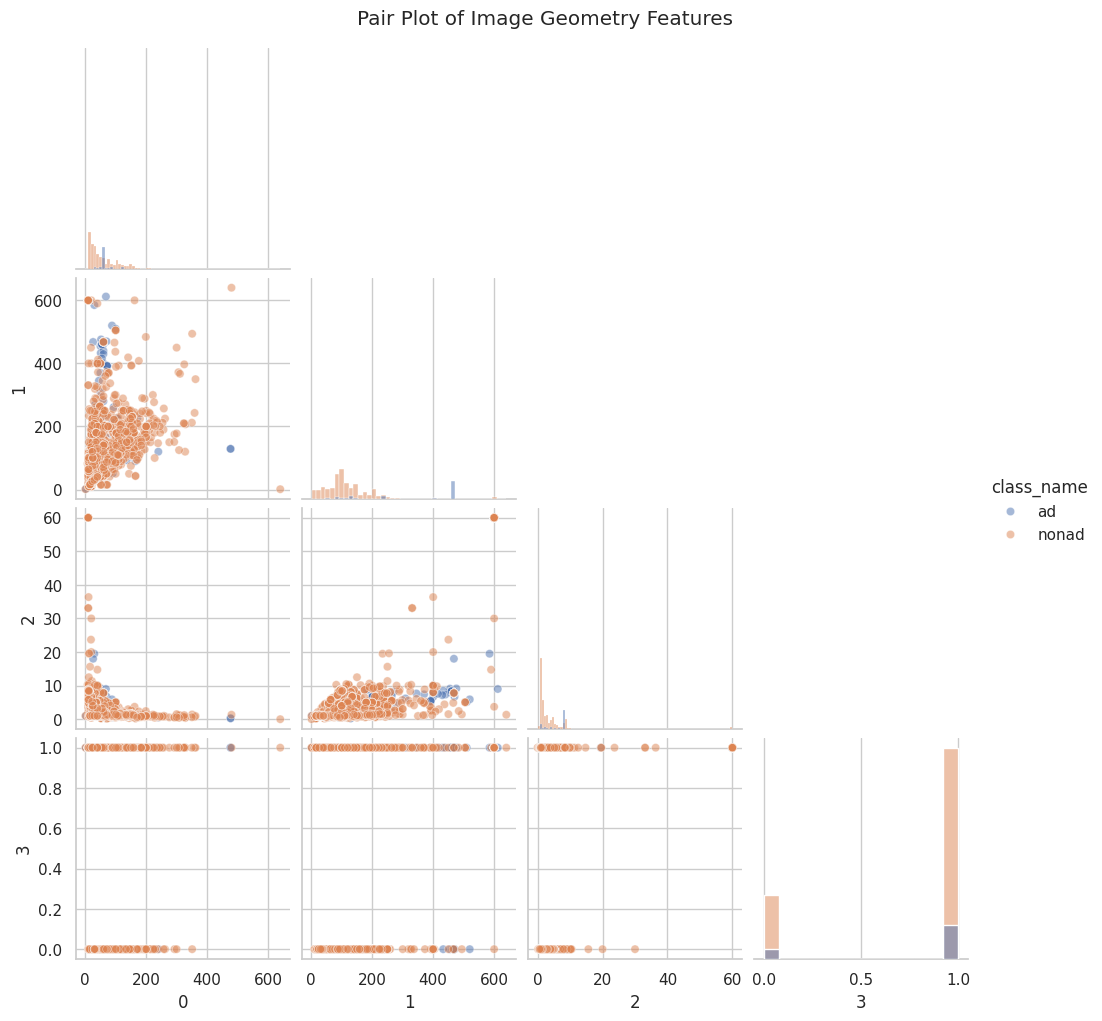

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the first 4 columns (physical dimensions)
geometry_features = df.columns[:4].tolist()

# Create a temporary DataFrame for plotting by combining geometry features and class_name
plot_df = df[geometry_features].copy()
plot_df['class_name'] = class_name # Add the class_name Series as a column

# Generate the pair plot
sns.pairplot(
    plot_df, # Use the new combined DataFrame
    hue="class_name",
    corner=True,
    diag_kind="hist",
    plot_kws={'alpha': 0.5} # Makes overlapping points easier to see
)

plt.suptitle("Pair Plot of Image Geometry Features", y=1.02)
plt.show()

## 8. Correlation heatmap

A correlation heatmap shows whether features move together.

### Important note
Correlation does **not** mean causation, but it helps us understand relationships between variables.

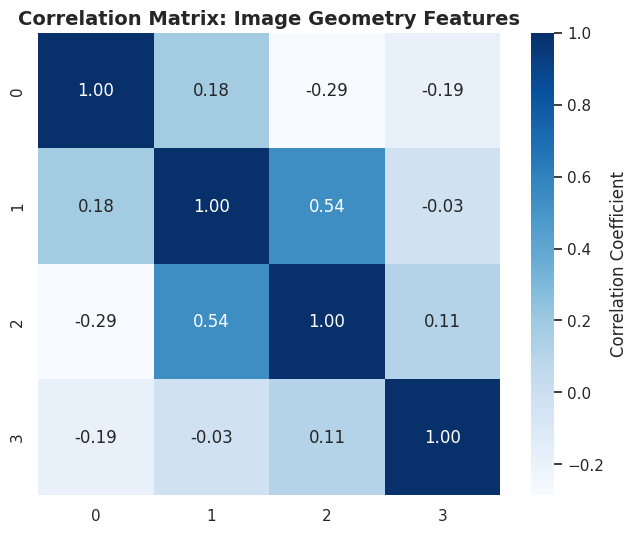

In [ ]:
# Select the first 4 numeric columns (Geometry features)
geometry_features = df.columns[:4].tolist()

# Calculate correlations for those specific features
corr = df[geometry_features].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation Matrix: Image Geometry Features", fontsize=14, weight="bold")
plt.show()

## 9. Define the features and target

In machine learning:
- **X** usually means the input features
- **y** usually means the target we want to predict

Here, the input is flower measurements, and the target is the species name.

In [ ]:
# X contains all predictor variables (dropping the class columns and names)
# We drop 'class', 'class_id', and 'class_name' to keep only the features
X = df

# y contains the labels ('ad' or 'nonad')
y = class_name

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 rows of features (showing first 5 of 1558 columns):")
display(X.iloc[:, :5].head())

Feature matrix shape: (3279, 1558)
Target shape: (3279,)

First 5 rows of features (showing first 5 of 1558 columns):


,0,1,2,3,4
0,125.0,125.0,1.0000,1.0,0
1,57.0,468.0,8.2105,1.0,0
2,33.0,230.0,6.9696,1.0,0
3,60.0,468.0,7.8000,1.0,0
4,60.0,468.0,7.8000,1.0,0


## 10. Split the data into training and testing sets

We train the model on one part of the data and test it on a different part.

### Why this matters
This gives us a more honest estimate of performance on unseen data.

In [ ]:
# Split the data into training and testing sets.
# stratify=y is especially important here because there are far more 'nonads' than 'ads'.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape (rows, features):", X_train.shape)
print("Testing set shape (rows, features):", X_test.shape)

print("\nTraining class distribution (Ad vs. Non-Ad):")
print(y_train.value_counts())

Training set shape (rows, features): (2623, 1558)
Testing set shape (rows, features): (656, 1558)

Training class distribution (Ad vs. Non-Ad):
1558
nonad    2256
ad        367
Name: count, dtype: int64


## 11. Build a simple baseline model

A baseline gives us a minimum standard to beat.

Here we use a **DummyClassifier** that always predicts the most frequent class.

### Why this matters
If a real model cannot beat the baseline, it is not useful.

In [ ]:
# Create and train a simple baseline classifier.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Make predictions on the test set.
baseline_pred = baseline.predict(X_test)

# Calculate the baseline accuracy.
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.860


## 12. Train multiple machine learning models

We will compare three models:
1. **K-Nearest Neighbors (KNN)**
2. **Logistic Regression**
3. **Decision Tree**

### Why use a pipeline?
A pipeline keeps preprocessing and modeling together in one clean workflow.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Updated models with Imputation, Scaling, and PCA
models = {
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)), # Reduces 1500+ features to 50
        ("model", KNeighborsClassifier())
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)),
        ("model", LogisticRegression(max_iter=500))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("pca", PCA(n_components=50)), # Scaling isn't strictly needed for Trees, but PCA is
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)),
        ("model", SVC(kernel='rbf', probability=True, random_state=42))
    ])
}
# The rest of your loop remains the same
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1 Score": f1_score(y_test, pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,CV Mean Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.949673,0.963415,0.962594,0.963415,0.962712
1,KNN,0.961877,0.961890,0.961195,0.961890,0.960449
2,Logistic Regression,0.959589,0.952744,0.951605,0.952744,0.950414
3,SVM,0.949669,0.952744,0.954279,0.952744,0.948915


## 13. Visualize model comparison

A table is useful, but a chart makes the comparison faster to understand.

### What to notice
Look for the model with the highest test accuracy.

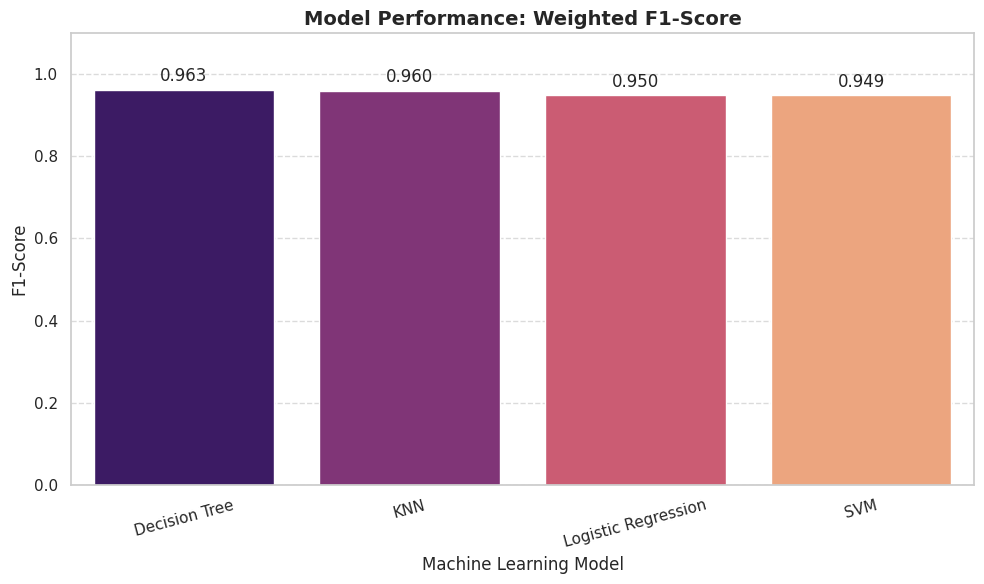

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot model F1-Score for a better comparison on imbalanced data.
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score", # Switched from Accuracy to F1 Score
    hue="Model",
    palette="magma",
    legend=False
)

plt.title("Model Performance: Weighted F1-Score", fontsize=14, weight="bold")
plt.ylim(0, 1.1) # Extra space for the labels
plt.ylabel("F1-Score")
plt.xlabel("Machine Learning Model")

# Show the metric value on top of each bar for precision.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 14. Tune the KNN model with GridSearchCV

After comparing models, we fine-tune KNN.

### What is happening here?
We test many combinations of:
- number of neighbors
- weight strategy
- distance metric

The goal is to find the combination that performs best in cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Rebuild the KNN pipeline for tuning, using the same preprocessing steps as in the model comparison.
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)), # Use PCA as defined in the models dictionary
    ("model", KNeighborsClassifier())
])

# Define the parameter combinations to test.
param_grid = {
    "model__n_neighbors": list(range(1, 16)), # Test 1 to 15 neighbors
    "model__weights": ["uniform", "distance"],
    "model__metric": ["minkowski", "euclidean", "manhattan"]
}

# GridSearchCV tries all parameter combinations and finds the best one.
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1 # Use all available CPU cores
)

# Fit the grid search on the training data.
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")

Best parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}
Best cross-validation accuracy: 0.969


In [ ]:
# Convert everything to numeric and turn errors (like "?") into NaNs
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Updated models with Imputation, Scaling, and PCA
models = {
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)), # Reduces 1500+ features to 50
        ("model", KNeighborsClassifier())
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=50)),
        ("model", LogisticRegression(max_iter=500))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy='median')),
        ("pca", PCA(n_components=50)), # Scaling isn't strictly needed for Trees, but PCA is
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}

# The rest of your loop remains the same
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1 Score": f1_score(y_test, pred, average="weighted")
    })

## 15. Evaluate the tuned KNN model

Now we use the **best** KNN model found during tuning and evaluate it on the test data.

In [ ]:
# Use the best tuned model to make predictions.
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Store the final evaluation metrics.
final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred, average="weighted")
}

pd.DataFrame(final_metrics, index=["Tuned KNN"]).T

,Tuned KNN
Accuracy,0.964634
Precision,0.964721
Recall,0.964634
F1 Score,0.962953


## 16. Print the classification report

A classification report shows performance for each class separately.

### Main terms
- **precision**: when the model predicts a class, how often is it correct?
- **recall**: how many real examples of that class did the model find?
- **f1-score**: a balance between precision and recall

In [ ]:
from sklearn.metrics import classification_report

# Print a detailed report for the ad classification results.
# 'y_test' contains the true labels ('ad' or 'nonad')
# 'y_pred' contains the labels your model predicted
print("Classification Report for Tuned KNN (Internet Ads):")
print(classification_report(y_test, y_pred))

Classification Report for Tuned KNN (Internet Ads):
              precision    recall  f1-score   support

          ad       0.97      0.77      0.86       115
        noad       0.96      1.00      0.98       705

    accuracy                           0.96       820
   macro avg       0.97      0.88      0.92       820
weighted avg       0.96      0.96      0.96       820



## 17. Display the confusion matrix

A confusion matrix shows where the model is correct and where it makes mistakes.

### How to read it
- values on the diagonal are correct predictions
- off-diagonal values are mistakes

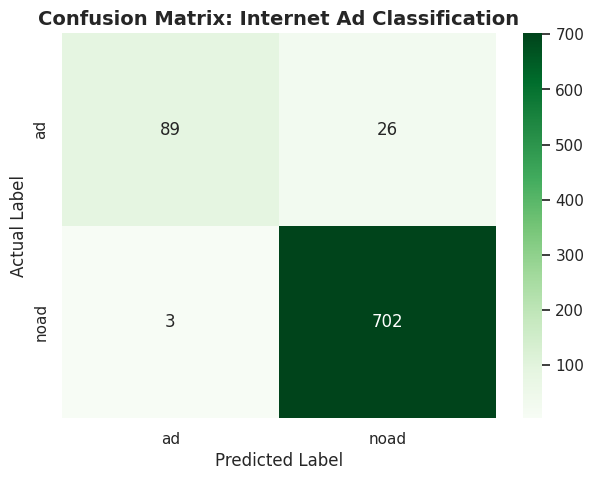

In [ ]:
from sklearn.metrics import confusion_matrix

# Use the unique classes from your target (usually ['ad', 'nonad'])
class_names = y.unique()

# Build the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_names)

# Plot the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens", # Switched color to distinguish from Iris
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix: Internet Ad Classification", fontsize=14, weight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 18. Compare actual and predicted values

This table lets students inspect individual predictions.

### Why this is useful
It helps connect the model's output back to actual rows from the dataset.

In [ ]:
# Create a comparison table for the test set.
comparison = X_test.copy()
comparison["Actual"] = y_test.values
comparison["Predicted"] = y_pred
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

comparison.head(10)

,height,width,aratio,local,url.images.buttons,url.likesbooks.com,url.www.slake.com,url.hydrogeologist,url.oso,url.media,...,caption.your,caption.in,caption.bytes,caption.here,caption.click,caption.for,caption.you,Actual,Predicted,Correct
1373,16,16,1.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
984,35,126,3.6,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
876,175,158,0.9028,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
1209,0,0,0.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
907,149,182,1.2214,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
326,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,ad,True
138,124,120,0.9677,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,ad,ad,True
1343,26,133,5.1153,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
569,100,0,0.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True
2982,0,0,0.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,noad,noad,True


## 19. Look at the mistakes

A strong habit in machine learning is to inspect the rows the model got wrong.

This helps us understand where the model struggles.

In [ ]:
# Count and display the incorrect predictions.
print("Number of incorrect predictions:", (~comparison["Correct"]).sum())

comparison[~comparison["Correct"]]

Number of incorrect predictions: 29


,height,width,aratio,local,url.images.buttons,url.likesbooks.com,url.www.slake.com,url.hydrogeologist,url.oso,url.media,...,caption.your,caption.in,caption.bytes,caption.here,caption.click,caption.for,caption.you,Actual,Predicted,Correct
1490,0,0,0.0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,noad,ad,False
422,60,440,7.3333,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
434,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
372,40,400,10.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
2745,0,0,0.0,1,0,0,0,0,0,0,...,0,0,0,1,1,0,0,noad,ad,False
241,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
455,50,150,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
276,50,370,7.4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
391,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False
105,20,58,2.9,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,ad,noad,False


## 20. Interpret a decision tree visually

Even if another model performs best, tree models are useful because they are easier to interpret visually.

### Why this matters
Interpretability helps us understand how a model is making decisions.

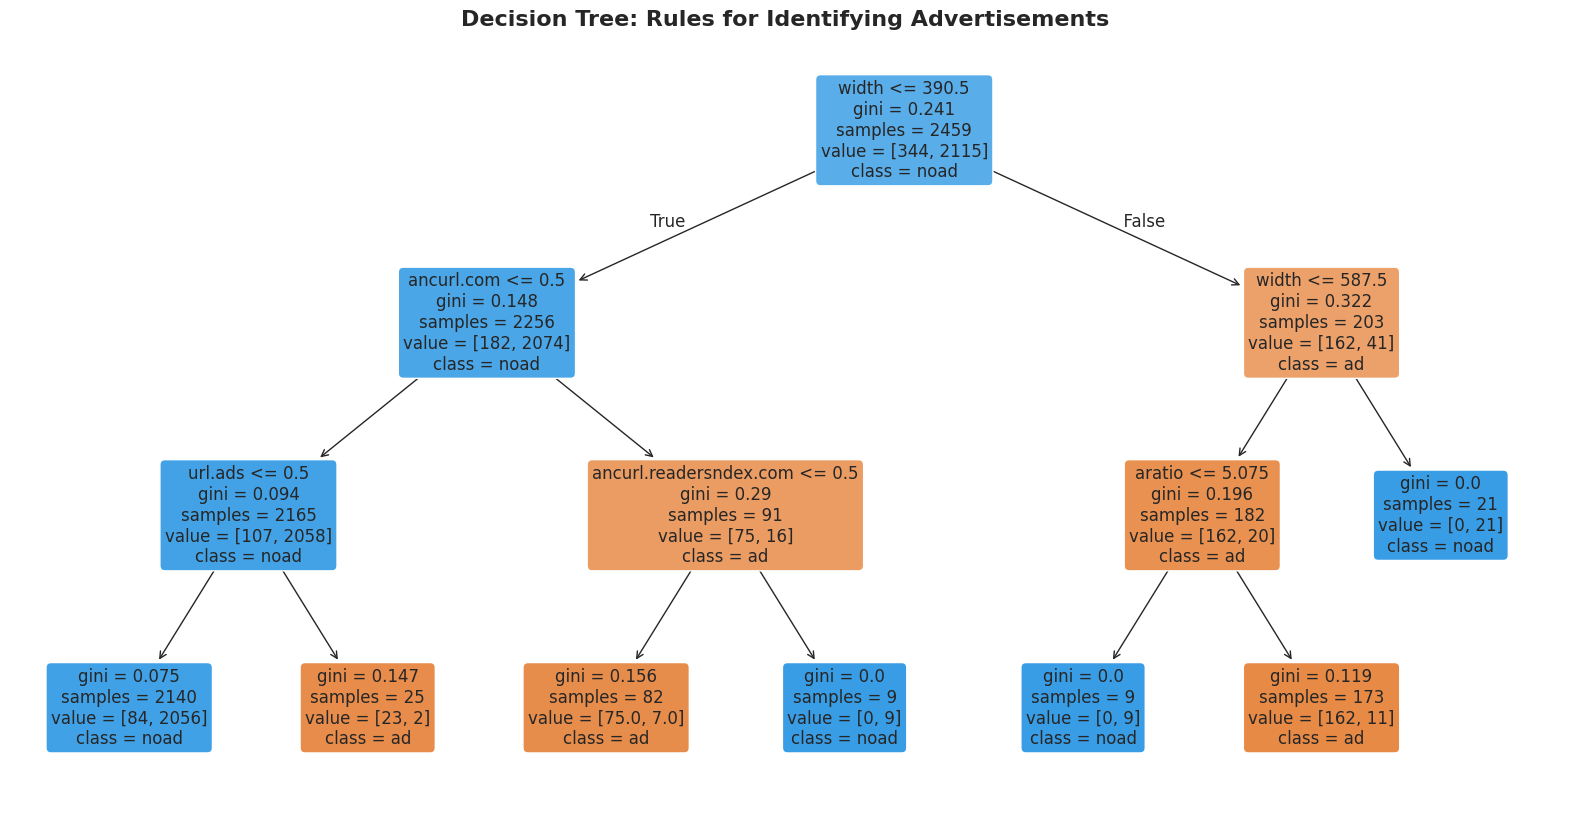

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. We train on raw X_train (not PCA) so the labels make sense
# We use a Pipeline just to handle the missing values (imputer)
interpret_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("model", DecisionTreeClassifier(max_depth=3, random_state=42))
])

# Fit the model
interpret_pipeline.fit(X_train, y_train)

# Pull the trained tree out of the pipeline for plotting
tree_model = interpret_pipeline.named_steps['model']

# 2. Plot the tree structure
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns.tolist(), # Uses the 1500+ real names (height, width, etc.)
    class_names=y.unique().tolist(),  # Uses 'ad' and 'nonad'
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree: Rules for Identifying Advertisements", fontsize=16, weight="bold")
plt.show()

## 21. Feature importance

Decision trees can estimate which features were most useful during splitting.

### Reminder
Feature importance is helpful, but it does not prove cause and effect.

In [ ]:
# Create a table of feature importances from the decision tree.
# We use X.columns to get the real names (height, width, url keywords, etc.)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Show only the top 10 features, as most of the 1500+ features will be 0.0
print("Top 10 Most Influential Features for Ad Detection:")
display(feature_importance.head(10))

Top 10 Most Influential Features for Ad Detection:


,Feature,Importance
0,width,0.563274
1,ancurl.com,0.266585
2,url.ads,0.097487
3,aratio,0.038151
4,ancurl.readersndex.com,0.034503
5,ancurl.FlowSoft.com,0.000000
6,ancurl.ring,0.000000
7,ancurl.1.cid,0.000000
8,ancurl.any.time,0.000000
9,ancurl.clickid,0.000000


## 22. Visualize feature importance

This plot makes it easier to see which variables mattered most to the decision tree.

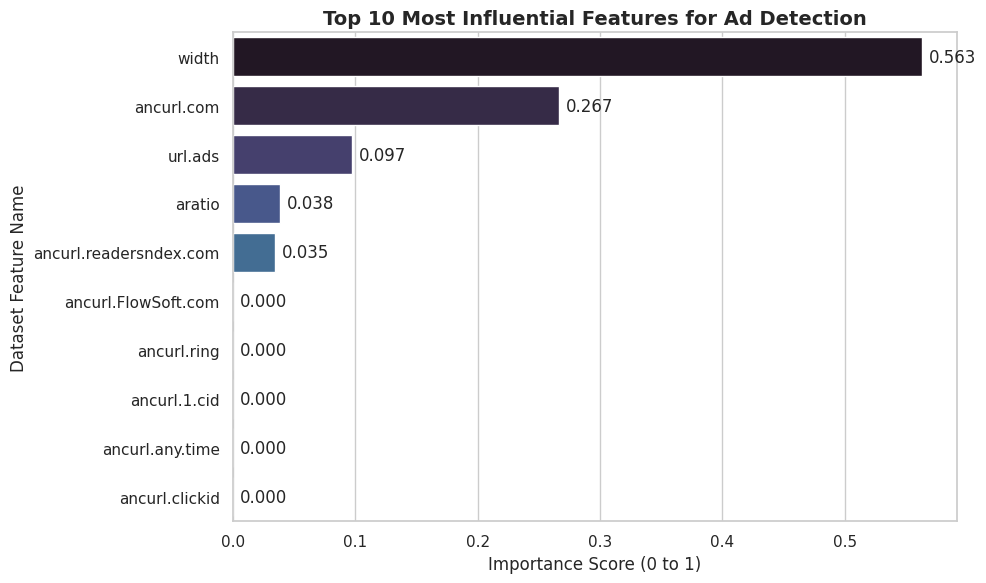

In [ ]:
# Select only the Top 10 features for a clean, readable chart
top_10_features = feature_importance.head(10)

# Plot feature importance from the decision tree.
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.title("Top 10 Most Influential Features for Ad Detection", fontsize=14, weight="bold")
plt.xlabel("Importance Score (0 to 1)")
plt.ylabel("Dataset Feature Name")

# Add the values to the end of the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5)

plt.tight_layout() # Ensures labels don't get cut off
plt.show()

## 24. Practice ideas

Try these extensions on your own:

1. Change the test size from **25%** to **30%** and compare results.
2. Add another model such as **Random Forest**.
3. Tune **Logistic Regression** instead of KNN.
4. Create a new chart using only two features.
5. Write 3 to 5 sentences explaining which model you would choose and why.

> **Mini challenge:** Can you explain why some species are easier to classify than others?